# 03 — Forward Propagation End-to-End (TensorFlow / Keras)

Forward propagation is deterministic evaluation of the current parameters. **No learning happens in the forward pass.** It answers only:

> Given these inputs and the current weights/biases, what output does the network produce?

For a two-layer classifier:

$$
\mathbf{z}^{(1)}=W^{(1)}\mathbf{x}+\mathbf{b}^{(1)}
$$
$$
\mathbf{a}^{(1)}=\operatorname{{ReLU}}(\mathbf{z}^{(1)})
$$
$$
\mathbf{z}^{(2)}=W^{(2)}\mathbf{a}^{(1)}+\mathbf{b}^{(2)}
$$

`z^(2)` contains **logits**: unconstrained class evidence, not probabilities yet.


In [1]:
from pathlib import Path
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / 'mnist.npz'
MNIST_URL = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
if not MNIST_PATH.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
with np.load(MNIST_PATH) as data:
    x_train_raw, y_train_raw = data['x_train'], data['y_train']
    x_test_raw, y_test_raw = data['x_test'], data['y_test']
print('raw train:', x_train_raw.shape, y_train_raw.shape)
print('raw test :', x_test_raw.shape, y_test_raw.shape)


def balanced_subset(x, y, per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    ids = []
    for cls in range(10):
        candidates = np.flatnonzero(y == cls)
        ids.extend(rng.choice(candidates, size=per_class, replace=False))
    ids = np.array(ids)
    rng.shuffle(ids)
    return x[ids], y[ids]

x_train, y_train = balanced_subset(x_train_raw, y_train_raw, 500)
x_test, y_test = balanced_subset(x_test_raw, y_test_raw, 100)
X_train = x_train.reshape(len(x_train), -1).astype('float32') / 255.0
X_test = x_test.reshape(len(x_test), -1).astype('float32') / 255.0
print('teaching train:', X_train.shape, y_train.shape)
print('teaching test :', X_test.shape, y_test.shape)
print('pixel range   :', float(X_train.min()), 'to', float(X_train.max()))


raw train: (60000, 28, 28) (60000,)
raw test : (10000, 28, 28) (10000,)
teaching train: (5000, 784) (5000,)
teaching test : (1000, 784) (1000,)
pixel range   : 0.0 to 1.0


## Line-by-line interpretation of the framework code

1. Convert a mini-batch into framework tensors.
2. Construct `784 → 64` and `64 → 10` affine transformations.
3. Compute hidden pre-activations `z1`.
4. Apply ReLU to produce hidden activations `a1`.
5. Compute output logits.
6. Apply softmax only when probabilities are needed for interpretation.
7. Inspect every tensor shape to verify the algebra.


In [2]:
import tensorflow as tf
tf.random.set_seed(SEED)
X = tf.constant(X_train[:4], dtype=tf.float32)
layer1 = tf.keras.layers.Dense(64, activation=None)
layer2 = tf.keras.layers.Dense(10, activation=None)
z1 = layer1(X)
a1 = tf.nn.relu(z1)
logits = layer2(a1)
probs = tf.nn.softmax(logits, axis=1)
print('X      :', X.shape)
print('z1     :', z1.shape)
print('a1     :', a1.shape)
print('logits :', logits.shape)
print('probs  :', probs.shape)
print('row probability sum:', float(tf.reduce_sum(probs[0])))
print('predicted class:', int(tf.argmax(probs[0])), 'true:', int(y_train[0]))


2026-09-07 12:01:04.781643: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-07 12:01:04.808044: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


X      : (4, 784)
z1     : (4, 64)
a1     : (4, 64)
logits : (4, 10)
probs  : (4, 10)
row probability sum: 1.0
predicted class: 4 true: 9


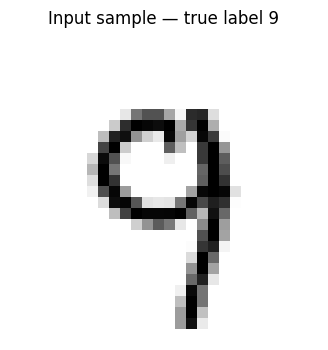

In [3]:
idx = 0
plt.figure(figsize=(4,4))
plt.imshow(x_train[idx], cmap='gray_r')
plt.title(f'Input sample — true label {int(y_train[idx])}')
plt.axis('off'); plt.show()


## Critical engineering rule

Loss functions such as cross-entropy usually accept **raw logits** because they combine softmax and logarithms in a numerically stable way. Do not apply softmax before the training loss unless the API explicitly requires probabilities.
